# EDA

### Импорты

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

### Конфигурация

In [3]:
USERNAME = os.getenv("DB_USERNAME")
PASSWORD = os.getenv("DB_PASSWORD")
HOST = os.getenv("DB_HOST")
PORT = os.getenv("DB_PORT")
DATABASE = os.getenv("DB_NAME")

url = URL.create(
    drivername="postgresql+psycopg2",
    username=USERNAME,
    password=PASSWORD,
    host=HOST,
    port=PORT,
    database=DATABASE,
)

In [4]:
connection = create_engine(url=url)

### Анализ

#### **CUSTOMERS**

In [5]:
read_sql_query = "SELECT * FROM customers"
df = pd.read_sql(sql=read_sql_query, con=connection)

In [6]:
df.head()

,customer_id,customer_unique_id,customer_city,customer_state,customer_zip_code_prefix
0,cb8adca2a68ffd5c23a6740bccf56ee7,324b9a2e37fc2ab928a842b9429c46ea,guarulhos,SP,07072
1,366c88e3ee5ed365c8529a9639c8b91c,8797820f6554668a5b835ff74cd077df,bage,RS,96400
2,05b050b67d4c33acf2ee9cc81e85ecff,5171fb2cd9c087cd23c02234f1988cfa,mage,RJ,25901
3,649ad21522182e99c6923493d5d181ca,a141cad9daad0a5e00543b930e249b48,leme,SP,13611
4,65b9b5ce785c22668628edb304992629,2ec20d01e0044bc8c80a9540cf156cb9,maua,SP,09361


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_city             99441 non-null  str  
 3   customer_state            99441 non-null  str  
 4   customer_zip_code_prefix  99441 non-null  str  
dtypes: str(5)
memory usage: 3.8 MB


In [8]:
df.describe(include='all')

,customer_id,customer_unique_id,customer_city,customer_state,customer_zip_code_prefix
count,99441,99441,99441,99441,99441
unique,99441,96096,4119,27,14994
top,cb8adca2a68ffd5c23a6740bccf56ee7,8d50f5eadf50201ccdcedfb9e2ac8455,sao paulo,SP,22790
freq,1,17,15540,41746,142


In [9]:
df.memory_usage(deep=True)

Index                           132
customer_id                 8054721
customer_unique_id          8054721
customer_city               5901273
customer_state              5071491
customer_zip_code_prefix    5369814
dtype: int64

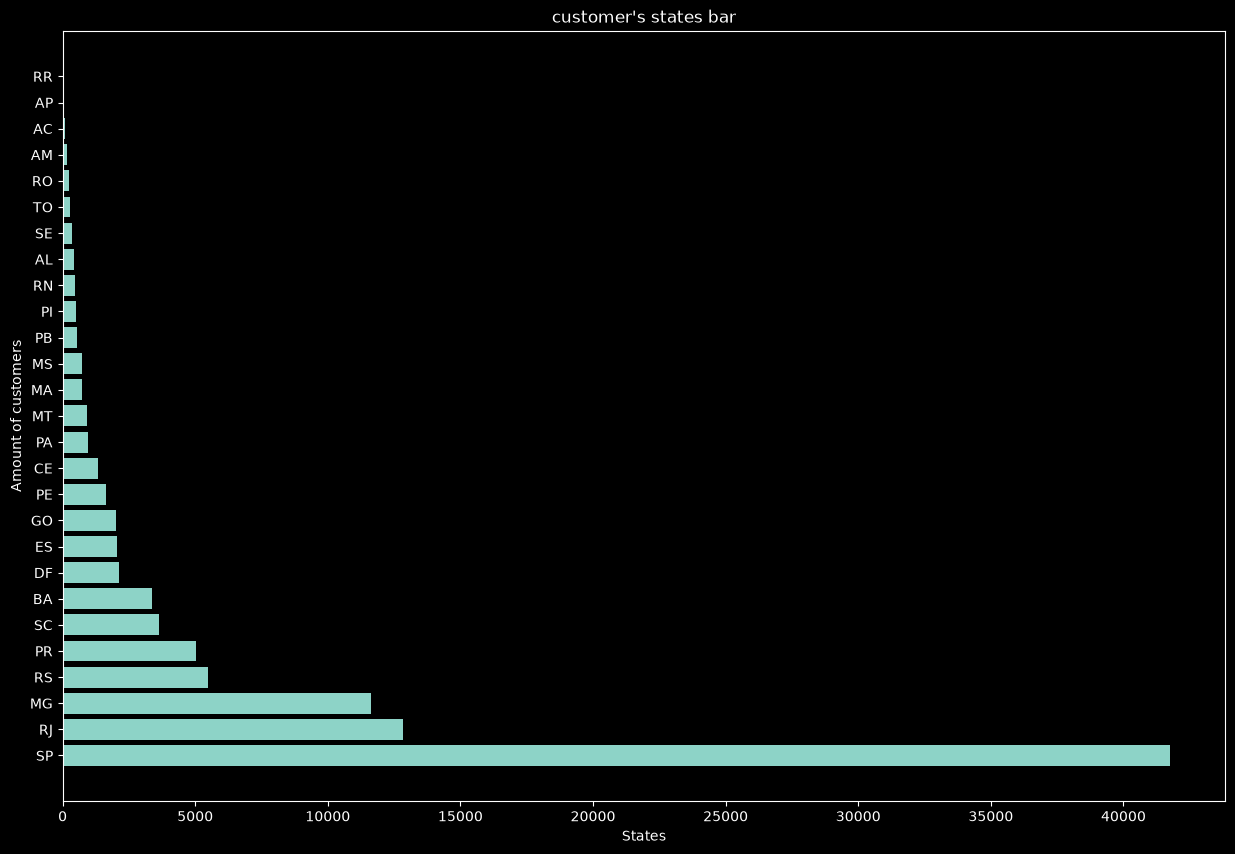

In [10]:
sampling_data = df['customer_state'].value_counts()

categories = sampling_data.index
values = sampling_data.values

plt.figure(figsize=(15, 10))
plt.barh(categories, values)

plt.title("customer's states bar")
plt.xlabel('States')
plt.ylabel('Amount of customers')

plt.show()

#### **SELLERS**

In [11]:
read_sql_query = "SELECT * FROM sellers"
df = pd.read_sql(sql=read_sql_query, con=connection)

In [12]:
df.head()

,seller_id,seller_city,seller_state,seller_zip_code_prefix
0,8bb48dc19fccaa8613b6229bf7f452a2,assis,SP,19803
1,a673821011d0cec28146ea42f5ab767f,sao paulo,SP,03809
2,a806a4bb063ea7ca6d374eafa50a6058,serra,ES,29161
3,61f159ef6da2d441951d2c0efa719362,serra,ES,29160
4,3442f8959a84dea7ee197c632cb2df15,campinas,SP,13023


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_city             3095 non-null   str  
 2   seller_state            3095 non-null   str  
 3   seller_zip_code_prefix  3095 non-null   str  
dtypes: str(4)
memory usage: 96.8 KB


In [14]:
df.describe(include='all')

,seller_id,seller_city,seller_state,seller_zip_code_prefix
count,3095,3095,3095,3095
unique,3095,609,23,2246
top,8bb48dc19fccaa8613b6229bf7f452a2,sao paulo,SP,14940
freq,1,695,1849,49


In [15]:
df.memory_usage(deep=True)

Index                        132
seller_id                 250695
seller_city               183121
seller_state              157845
seller_zip_code_prefix    167130
dtype: int64

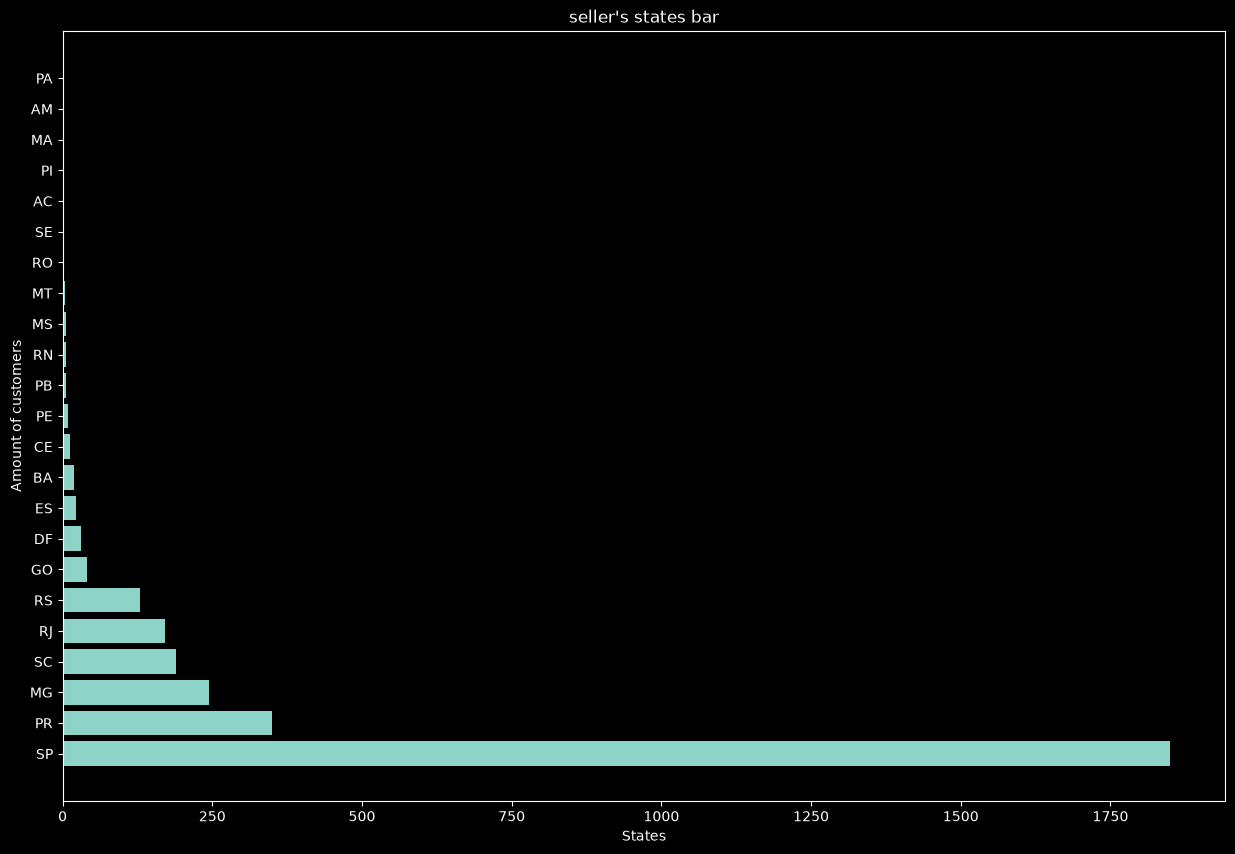

In [16]:
sampling_data = df['seller_state'].value_counts()

categories = sampling_data.index
values = sampling_data.values

plt.figure(figsize=(15, 10))
plt.barh(categories, values)

plt.title("seller's states bar")
plt.xlabel('States')
plt.ylabel('Amount of customers')

plt.show()

#### **PRODUCTS**

In [17]:
read_sql_query = ("SELECT "

                  "product_id, product_category_name_english, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm "

                  "FROM products "
                  "JOIN product_category_name_translation "
                  "USING (product_category_name)")

df = pd.read_sql(sql=read_sql_query, con=connection)

In [18]:
df.head()

,product_id,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,194e74feac1f84a8ee5a517d4b3e107a,computers,59,3913,2,14150.0,52.0,27.0,52.0
1,397192d59d6294262d63b01e93b3d4dd,pet_shop,60,316,2,1050.0,20.0,20.0,20.0
2,46eb4d4e006d97abd3bd84c23fcee7d9,perfumery,38,1597,1,150.0,20.0,20.0,20.0
3,2b8d2d937f84136de5b941aba77d4bcc,perfumery,53,273,1,486.0,23.0,13.0,19.0
4,d938227f7f7591d77e900cf3df3a645d,health_beauty,49,2938,1,2300.0,35.0,13.0,13.0


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32328 entries, 0 to 32327
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     32328 non-null  str    
 1   product_category_name_english  32328 non-null  str    
 2   product_name_lenght            32328 non-null  int64  
 3   product_description_lenght     32328 non-null  int64  
 4   product_photos_qty             32328 non-null  int64  
 5   product_weight_g               32327 non-null  float64
 6   product_length_cm              32327 non-null  float64
 7   product_height_cm              32327 non-null  float64
 8   product_width_cm               32327 non-null  float64
dtypes: float64(4), int64(3), str(2)
memory usage: 2.2 MB


In [20]:
df.describe(include='all')

,product_id,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32328,32328,32328.000000,32328.000000,32328.000000,32327.000000,32327.000000,32327.000000,32327.000000
unique,32328,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,194e74feac1f84a8ee5a517d4b3e107a,bed_bath_table,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.474078,771.520168,2.188815,2276.960807,30.856498,16.955950,23.208464
std,NaN,NaN,10.246388,635.180062,1.736746,4279.734063,16.958460,13.637246,12.080665
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,20.500000,30.000000


In [21]:
df.memory_usage(deep=True)

Index                                132
product_id                       2618568
product_category_name_english    2002411
product_name_lenght               258624
product_description_lenght        258624
product_photos_qty                258624
product_weight_g                  258624
product_length_cm                 258624
product_height_cm                 258624
product_width_cm                  258624
dtype: int64

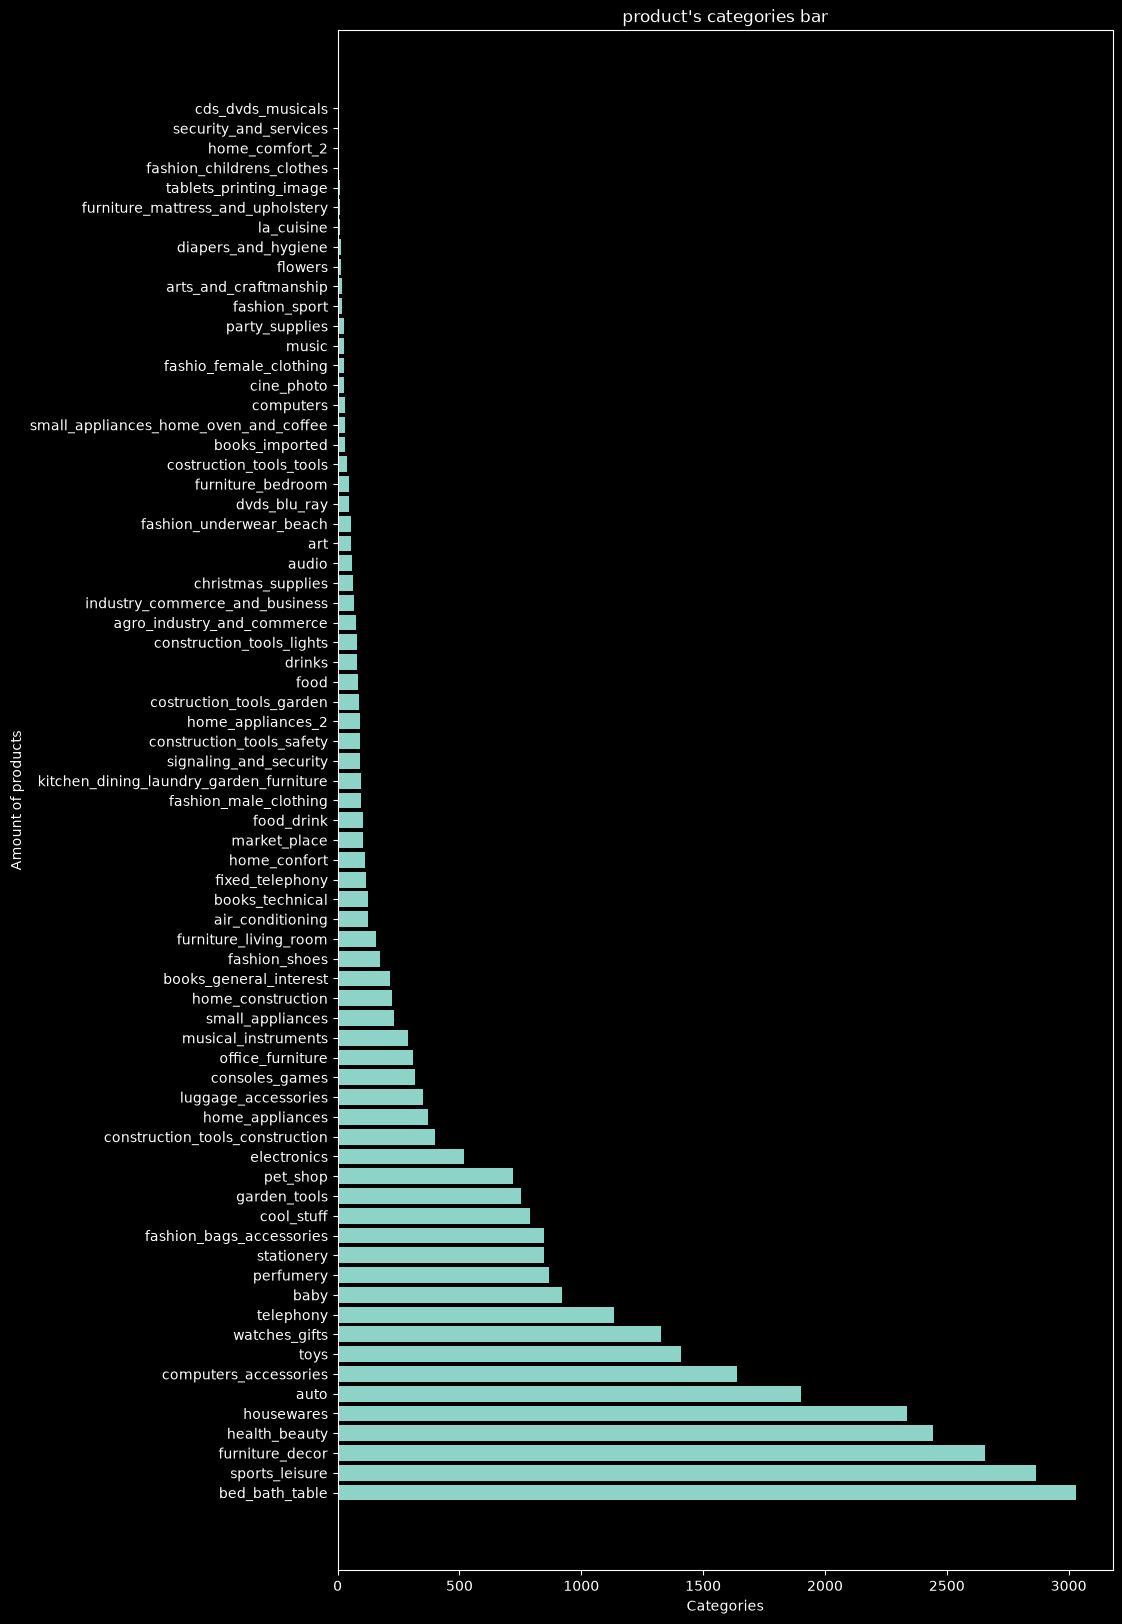

In [22]:
sampling_data = df['product_category_name_english'].value_counts()

categories = sampling_data.index
values = sampling_data.values

plt.figure(figsize=(10, 20))
plt.barh(categories, values)

plt.title("product's categories bar")
plt.xlabel('Categories')
plt.ylabel('Amount of products')

plt.show()

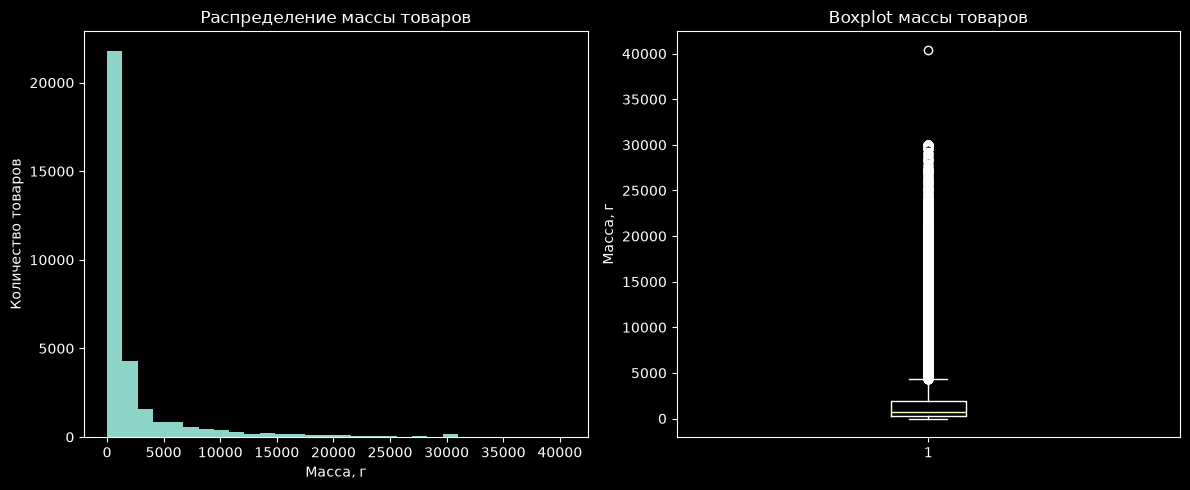

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(
    df["product_weight_g"].dropna(),
    bins=30
)

axes[0].set_title("Распределение массы товаров")
axes[0].set_xlabel("Масса, г")
axes[0].set_ylabel("Количество товаров")

axes[1].boxplot(
    df["product_weight_g"].dropna()
)

axes[1].set_title("Boxplot массы товаров")
axes[1].set_ylabel("Масса, г")

plt.tight_layout()
plt.show()

#### **ORDERS**

In [24]:
read_sql_query = "SELECT * FROM orders"
df = pd.read_sql(sql=read_sql_query, con=connection)

In [25]:
df.head()

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_id
0,174118fa0e1dc8d43eaea511a68402e0,invoiced,2017-10-25 17:17:47,2017-10-25 17:28:24,NaT,NaT,2017-11-07,f212ed32824070dc30651f0bbba90b9b
1,ae16a4774354e48d2a9a8c43c685b30d,processing,2017-03-04 20:05:28,2017-03-04 20:15:21,NaT,NaT,2017-03-27,b5c8b2cf65bd49d6d1462ae6489fea43
2,896fbd78a9ef3839b34b893f48f6bc67,canceled,2018-05-12 01:48:33,NaT,NaT,NaT,2018-05-30,20153d17ff713721abd8b4c082d5e4d5
3,5a7ae4ca802c14fdff19558a4fee8727,invoiced,2016-10-10 17:16:03,2016-10-12 03:01:52,NaT,NaT,2016-12-06,3140c5d46f2d38e4f14a9675359d6a27
4,6e98de3a85c84ead6689189b825d35b5,canceled,2018-03-15 10:07:02,2018-03-15 10:29:33,NaT,NaT,2018-04-09,f34a6e874087ec1f0e3dab9fdf659c5d


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   order_status                   99441 non-null  str           
 2   order_purchase_timestamp       99441 non-null  datetime64[us]
 3   order_approved_at              99281 non-null  datetime64[us]
 4   order_delivered_carrier_date   97658 non-null  datetime64[us]
 5   order_delivered_customer_date  96476 non-null  datetime64[us]
 6   order_estimated_delivery_date  99441 non-null  datetime64[us]
 7   customer_id                    99441 non-null  str           
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [27]:
df.describe(include='all')

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_id
count,99441,99441,99441,99281,97658,96476,99441,99441
unique,99441,8,NaN,NaN,NaN,NaN,NaN,99441
top,174118fa0e1dc8d43eaea511a68402e0,delivered,NaN,NaN,NaN,NaN,NaN,f212ed32824070dc30651f0bbba90b9b
freq,1,96478,NaN,NaN,NaN,NaN,NaN,1
mean,NaN,NaN,2017-12-31 08:43:12.776581,2017-12-31 18:35:24.098800,2018-01-04 21:49:48.138278,2018-01-14 12:09:19.035542,2018-01-24 03:08:37.730111,NaN
min,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,NaN
25%,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.250000,2017-09-25 22:07:22.250000,2017-10-03 00:00:00,NaN
50%,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,NaN
75%,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.250000,2018-05-25 00:00:00,NaN
max,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,NaN


In [28]:
df.memory_usage(deep=True)

Index                                132
order_id                         8054721
order_status                     5765932
order_purchase_timestamp          795528
order_approved_at                 795528
order_delivered_carrier_date      795528
order_delivered_customer_date     795528
order_estimated_delivery_date     795528
customer_id                      8054721
dtype: int64

In [29]:
first_date = df["order_purchase_timestamp"].min()
last_date = df["order_purchase_timestamp"].max()

duration = last_date - first_date

print(f"Дата первого заказа: {first_date}\n"
      f"Дата последнего заказа: {last_date}\n"
      f"Временной отрезок торговли: {duration}")

Дата первого заказа: 2016-09-04 21:15:19
Дата последнего заказа: 2018-10-17 17:30:18
Временной отрезок торговли: 772 days 20:14:59


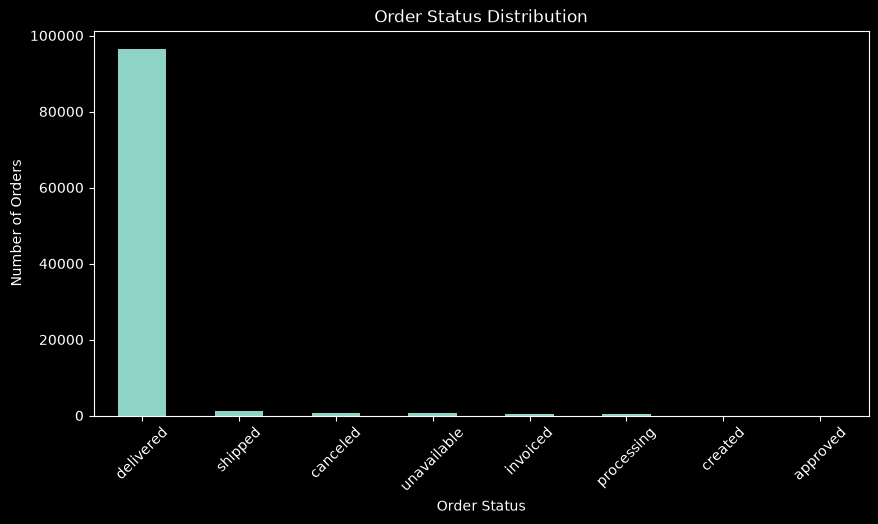

In [30]:
df["order_status"].value_counts().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

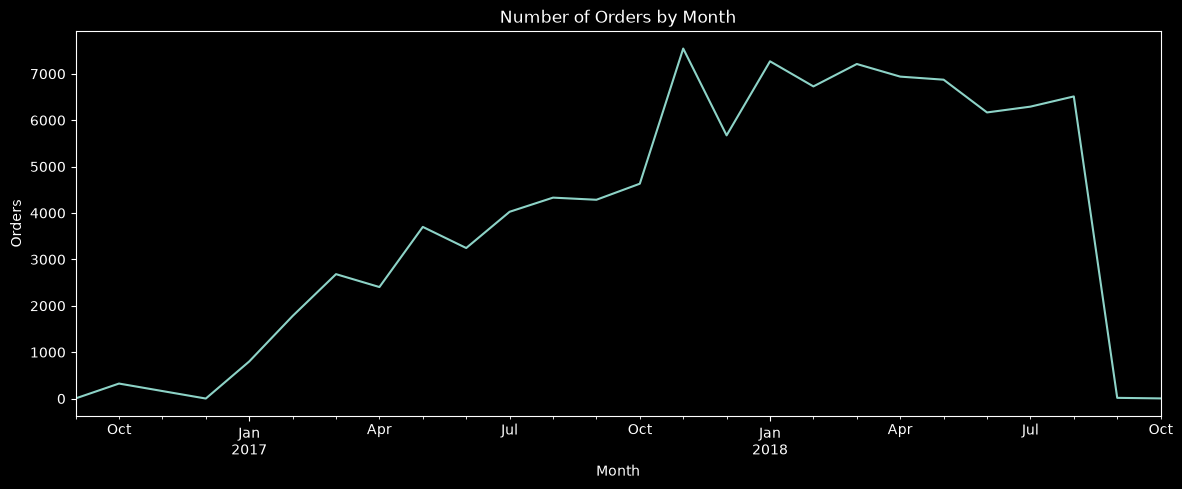

In [31]:
df["purchase_month"] = (
    df["order_purchase_timestamp"]
    .dt.to_period("M")
)

orders_by_month = (
    df.groupby("purchase_month")
    .size()
)

orders_by_month.plot(
    figsize=(14, 5)
)

plt.title("Number of Orders by Month")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.show()

In [32]:
df["delivery_days"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.total_seconds() / 86400

print('Статистика по дням доставки')
df["delivery_days"].describe()

Статистика по дням доставки


count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_days, dtype: float64

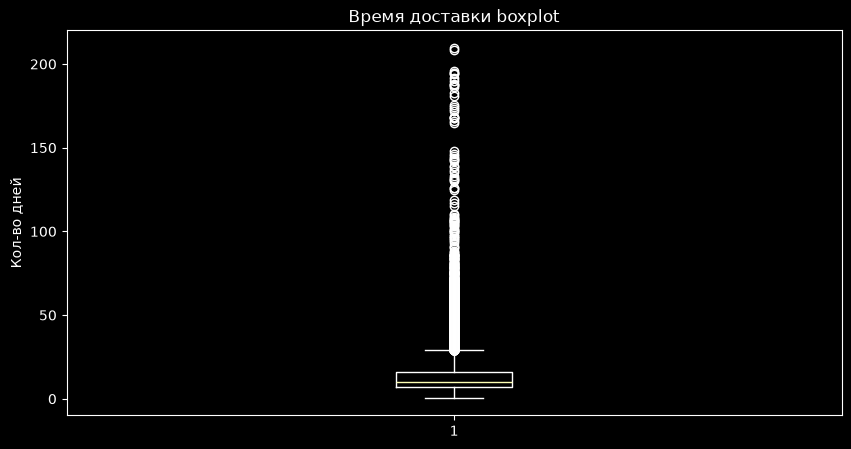

In [33]:
plt.figure(figsize=(10, 5))

plt.boxplot(df["delivery_days"].dropna())

plt.title("Время доставки boxplot")
plt.ylabel("Кол-во дней")

plt.show()

In [34]:
delivery_delay_days = df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
delivery_delay_days.dropna(inplace=True)
delivery_delay_days = delivery_delay_days.dt.days

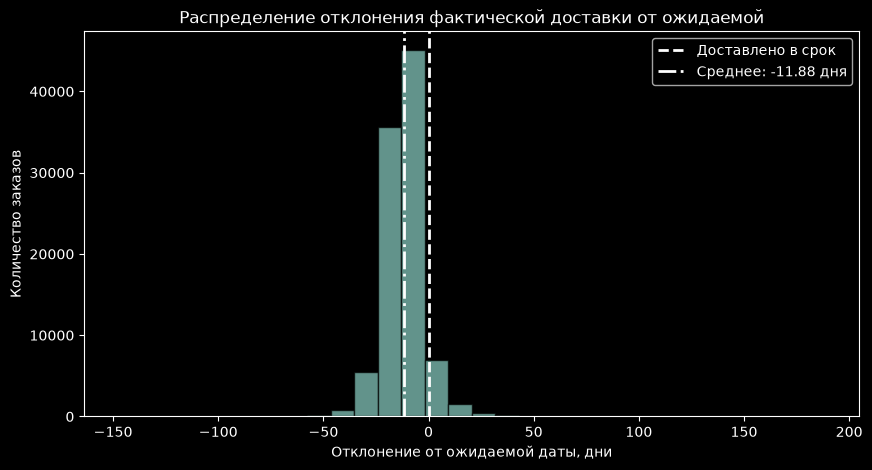

In [35]:
plt.figure(figsize=(10, 5))

plt.hist(
    delivery_delay_days,
    bins=30,
    edgecolor="black",
    alpha=0.7
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="Доставлено в срок"
)

mean_delay = delivery_delay_days.mean()

plt.axvline(
    mean_delay,
    linestyle="-.",
    linewidth=2,
    label=f"Среднее: {mean_delay:.2f} дня"
)

plt.xlabel("Отклонение от ожидаемой даты, дни")
plt.ylabel("Количество заказов")
plt.title("Распределение отклонения фактической доставки от ожидаемой")
plt.legend()

plt.show()

In [36]:
status = delivery_delay_days.apply(lambda x: 'Раньше срока' if x < 0 else ('Позже срока' if x > 0 else 'В срок') )
status = status.value_counts()

values = status.values
labels = status.index

total = values.sum()
percentages = values / total * 100

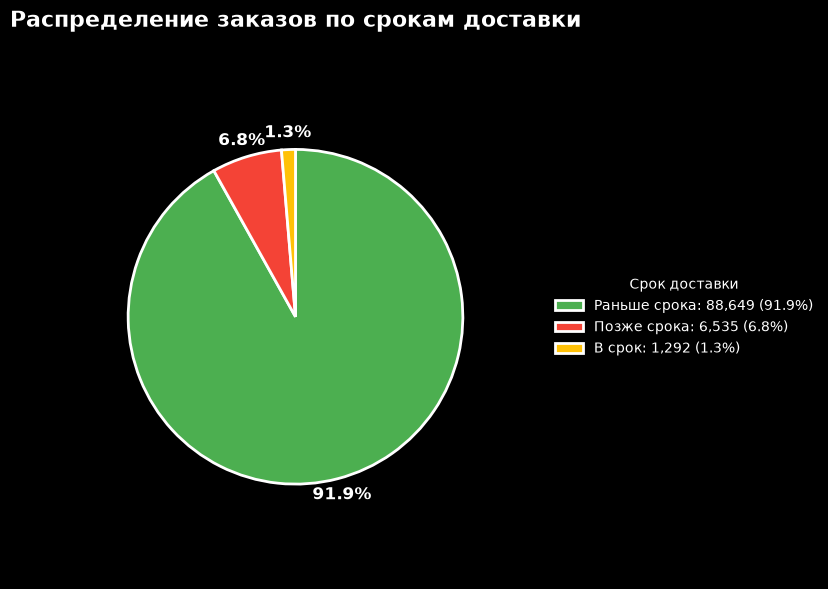

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))

color_map = {
    "Раньше срока": "#4CAF50",
    "В срок": "#FFC107",
    "Позже срока": "#F44336"
}

colors = [
    color_map[label]
    for label in labels
]

wedges, texts, autotexts = ax.pie(
    values,
    labels=None,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%",
    startangle=90,
    counterclock=False,
    pctdistance=1.1,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2
    }
)

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(12)
    autotext.set_fontweight("bold")

ax.set_title(
    "Распределение заказов по срокам доставки",
    fontsize=16,
    fontweight="bold",
    pad=20
)

legend_labels = [
    f"{label}: {value:,} ({pct:.1f}%)"
    for label, value, pct in zip(labels, values, percentages)
]

ax.legend(
    wedges,
    legend_labels,
    title="Срок доставки",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

ax.axis("equal")

plt.tight_layout()
plt.show()

#### **ORDER_REVIEWS**

In [38]:
read_sql_query = "SELECT * FROM order_reviews"
df = pd.read_sql(sql=read_sql_query, con=connection)

In [39]:
df.head()

,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_id
0,adb1d5514dc49d9c6311197ef7598804,4,-,-,2018-08-09,2018-08-09 21:25:19,0dfa86a9022c9929b3d7311150151f68
1,7bc2406110b926393aa56f80a40eba40,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59,73fc7af87114b39712e6da79b0a377eb
2,80e641a11e56f04c1ad469d5645fdfde,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13,a548910a1c6147796b98fdf73dbeba33
3,228ce5500dc1d8e020d8d1322874b6f0,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24,f9e4b658b201a9f2ecdecbb34bed034b
4,e64fb393e7b32834bb789ff8bb30750e,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06,658677c97b385a9be170737859d3511b


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  str           
 1   review_score             99224 non-null  int64         
 2   review_comment_title     99224 non-null  str           
 3   review_comment_message   99224 non-null  str           
 4   review_creation_date     99224 non-null  datetime64[us]
 5   review_answer_timestamp  99224 non-null  datetime64[us]
 6   order_id                 99224 non-null  str           
dtypes: datetime64[us](2), int64(1), str(4)
memory usage: 5.3 MB


In [41]:
df.describe(include='all')

,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_id
count,99224,99224.000000,99224,99224,99224,99224,99224
unique,98410,NaN,4528,36160,NaN,NaN,98673
top,c444278834184f72b1484dfe47de7f97,NaN,NaN,NaN,NaN,NaN,c88b1d1b157a9999ce368f218a407141
freq,3,NaN,87656,58247,NaN,NaN,3
mean,NaN,4.086421,NaN,NaN,2018-01-12 20:49:23.948238,2018-01-16 00:23:56.977938,NaN
min,NaN,1.000000,NaN,NaN,2016-10-02 00:00:00,2016-10-07 18:32:28,NaN
25%,NaN,4.000000,NaN,NaN,2017-09-23 00:00:00,2017-09-27 01:53:27.250000,NaN
50%,NaN,5.000000,NaN,NaN,2018-02-02 00:00:00,2018-02-04 22:41:47.500000,NaN
75%,NaN,5.000000,NaN,NaN,2018-05-16 00:00:00,2018-05-20 12:11:21.500000,NaN
max,NaN,5.000000,NaN,NaN,2018-08-31 00:00:00,2018-10-29 12:27:35,NaN


In [42]:
df.memory_usage(deep=True)

Index                          132
review_id                  8037144
review_score                793792
review_comment_title       5306266
review_comment_message     8274420
review_creation_date        793792
review_answer_timestamp     793792
order_id                   8037144
dtype: int64

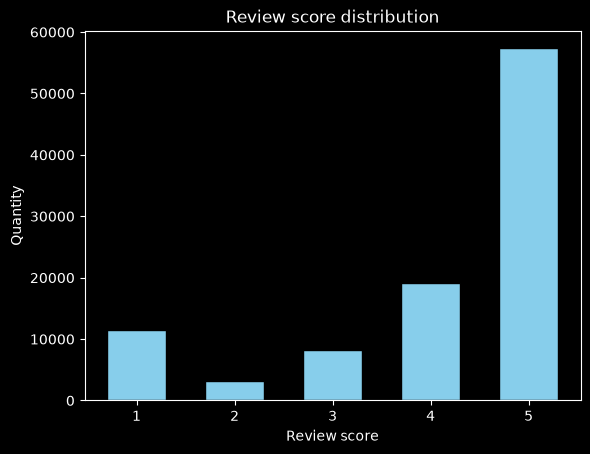

In [43]:
review_score_counts = df['review_score'].value_counts()

plt.bar(review_score_counts.index, review_score_counts.values, color='skyblue', edgecolor='black', width=0.6)

plt.title('Review score distribution')
plt.xlabel('Review score')
plt.ylabel('Quantity')

plt.show()

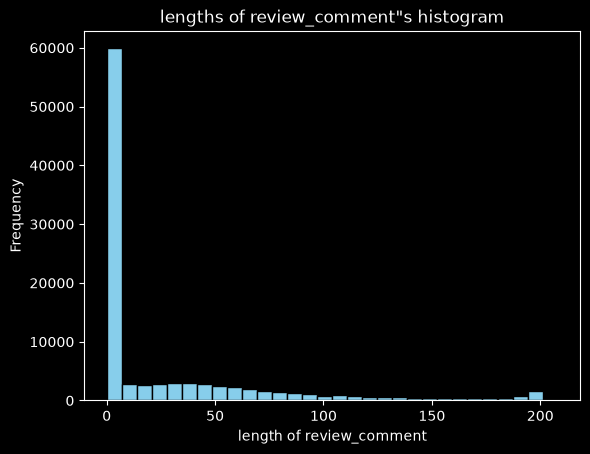

In [44]:
data = df["review_comment_message"].apply(lambda x: len(x) if x != "NaN" else 0)

plt.hist(data, bins=30, edgecolor='black', color='skyblue')

plt.xlabel('length of review_comment')
plt.ylabel('Frequency')
plt.title('lengths of review_comment"s histogram')

plt.show()

#### **ORDER_PAYMENTS**

In [45]:
read_sql_query = "SELECT * FROM order_payments"
df = pd.read_sql(sql=read_sql_query, con=connection)

In [46]:
df.head()

,payment_sequential,payment_type,payment_installments,payment_value,order_id
0,1,credit_card,8,99.33,b81ef226f3fe1789b1e8b2acac839d17
1,1,credit_card,1,24.39,a9810da82917af2d9aefd1278f1dcfa0
2,1,credit_card,1,65.71,25e8ea4e93396b6fa0d3dd708e76c1bd
3,1,credit_card,8,107.78,ba78997921bbcdc1373bb41e913ab953
4,1,credit_card,2,128.45,42fdf880ba16b47b59251dd489d4441a


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   payment_sequential    103886 non-null  int64  
 1   payment_type          103886 non-null  str    
 2   payment_installments  103886 non-null  int64  
 3   payment_value         103886 non-null  float64
 4   order_id              103886 non-null  str    
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [48]:
df.describe(include='all')

,payment_sequential,payment_type,payment_installments,payment_value,order_id
count,103886.000000,103886,103886.000000,103886.000000,103886
unique,NaN,5,NaN,NaN,99440
top,NaN,credit_card,NaN,NaN,fa65dad1b0e818e3ccc5cb0e39231352
freq,NaN,76795,NaN,NaN,29
mean,1.092679,NaN,2.853349,154.100380,NaN
std,0.706584,NaN,2.687051,217.494064,NaN
min,1.000000,NaN,0.000000,0.000000,NaN
25%,1.000000,NaN,1.000000,56.790000,NaN
50%,1.000000,NaN,1.000000,100.000000,NaN
75%,1.000000,NaN,4.000000,171.837500,NaN


In [49]:
df.memory_usage(deep=True)

Index                       132
payment_sequential       831088
payment_type            6109611
payment_installments     831088
payment_value            831088
order_id                8414766
dtype: int64

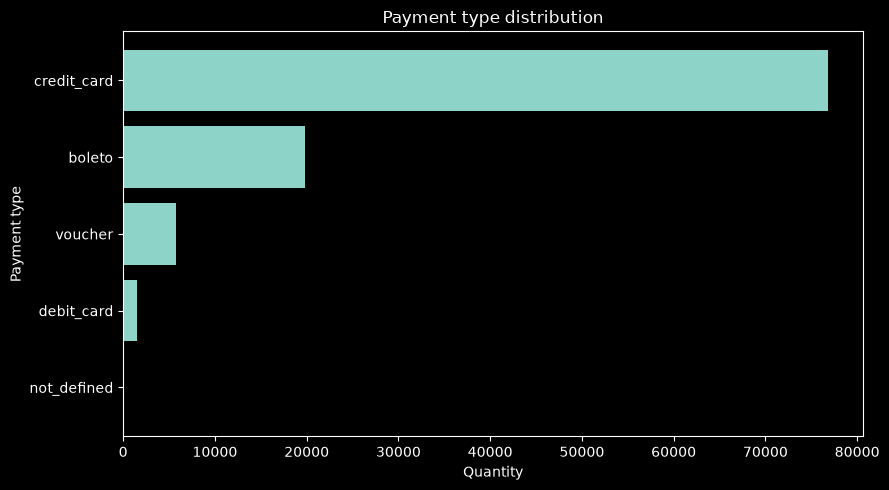

In [50]:
payment_counts = df["payment_type"].value_counts()

plt.figure(figsize=(9, 5))

bars = plt.barh(
    payment_counts.index,
    payment_counts.values
)

plt.xlabel("Quantity")
plt.ylabel("Payment type")
plt.title("Payment type distribution")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

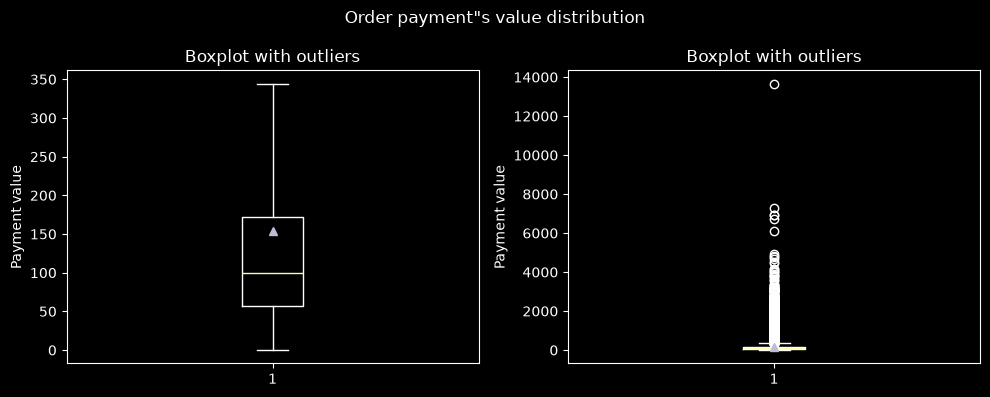

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Order payment"s value distribution')

ax[0].boxplot(
    df["payment_value"].dropna(),
    showmeans=True,
    showfliers=False,
)
ax[0].set_title("Boxplot with outliers")
ax[0].set_ylabel("Payment value")

ax[1].boxplot(
    df["payment_value"].dropna(),
    showmeans=True,
    showfliers=True,
)
ax[1].set_title("Boxplot with outliers")
ax[1].set_ylabel("Payment value")

plt.tight_layout()
plt.show()

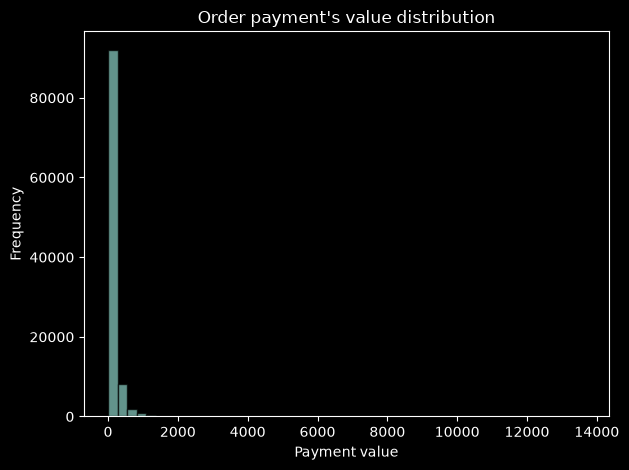

In [52]:
plt.hist(
    df["payment_value"].dropna(),
    bins=50,
    edgecolor="black",
    alpha=0.7
)
plt.title("Order payment's value distribution")
plt.xlabel("Payment value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

#### **ORDER_ITEMS**

In [59]:
read_sql_query = "SELECT * FROM order_items"
df = pd.read_sql(sql=read_sql_query, con=connection)

In [60]:
df.head()

,order_item_id,order_id,shipping_limit_date,price,freight_value,product_id,seller_id
0,1,00010242fe8c5a6d1ba2dd792cb16214,2017-09-19 09:45:35,58.90,13.29,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202
1,1,00018f77f2f0320c557190d7a144bdd3,2017-05-03 11:05:13,239.90,19.93,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36
2,1,000229ec398224ef6ca0657da4fc703e,2018-01-18 14:48:30,199.00,17.87,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d
3,1,00024acbcdf0a6daa1e931b038114c75,2018-08-15 10:10:18,12.99,12.79,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4
4,1,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-13 13:57:51,199.90,18.14,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_item_id        112650 non-null  int64         
 1   order_id             112650 non-null  str           
 2   shipping_limit_date  112650 non-null  datetime64[us]
 3   price                112650 non-null  float64       
 4   freight_value        112650 non-null  float64       
 5   product_id           112650 non-null  str           
 6   seller_id            112650 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.0 MB


In [62]:
df.describe(include='all')

,order_item_id,order_id,shipping_limit_date,price,freight_value,product_id,seller_id
count,112650.000000,112650,112650,112650.000000,112650.000000,112650,112650
unique,NaN,98666,NaN,NaN,NaN,32951,3095
top,NaN,8272b63d03f5f79c56e9e4120aec44ef,NaN,NaN,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0
freq,NaN,21,NaN,NaN,NaN,527,2033
mean,1.197834,NaN,2018-01-07 15:36:52.192685,120.653739,19.990320,NaN,NaN
min,1.000000,NaN,2016-09-19 00:15:34,0.850000,0.000000,NaN,NaN
25%,1.000000,NaN,2017-09-20 20:57:27.500000,39.900000,13.080000,NaN,NaN
50%,1.000000,NaN,2018-01-26 13:59:35,74.990000,16.260000,NaN,NaN
75%,1.000000,NaN,2018-05-10 14:34:00.750000,134.900000,21.150000,NaN,NaN
max,21.000000,NaN,2020-04-09 22:35:08,6735.000000,409.680000,NaN,NaN


In [63]:
df.memory_usage(deep=True)

Index                      132
order_item_id           901200
order_id               9124650
shipping_limit_date     901200
price                   901200
freight_value           901200
product_id             9124650
seller_id              9124650
dtype: int64

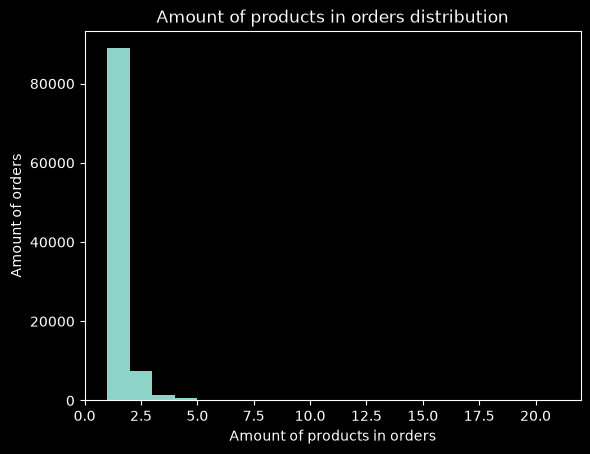

In [68]:
items_per_order = (
    df.groupby("order_id")["order_item_id"]
    .max()
)
plt.hist(items_per_order, bins=20)

plt.xlabel("Amount of products in orders")
plt.ylabel("Amount of orders")
plt.title("Amount of products in orders distribution")

plt.show()

#### **GEOLOCATION**

In [69]:
read_sql_query = "SELECT * FROM geolocation"
df = pd.read_sql(sql=read_sql_query, con=connection)

In [70]:
df.head()

,geolocation_id,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1,01037,-23.545621,-46.639292,sao paulo,SP
1,2,01046,-23.546081,-46.644820,sao paulo,SP
2,3,01046,-23.546129,-46.642951,sao paulo,SP
3,4,01041,-23.544392,-46.639499,sao paulo,SP
4,5,01035,-23.541578,-46.641607,sao paulo,SP


In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000326 entries, 0 to 2000325
Data columns (total 6 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   geolocation_id               int64  
 1   geolocation_zip_code_prefix  str    
 2   geolocation_lat              float64
 3   geolocation_lng              float64
 4   geolocation_city             str    
 5   geolocation_state            str    
dtypes: float64(2), int64(1), str(3)
memory usage: 91.6 MB


In [72]:
df.describe(include='all')

,geolocation_id,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,2.000326e+06,2000326,2.000326e+06,2.000326e+06,2000326,2000326
unique,NaN,19015,NaN,NaN,5968,27
top,NaN,24220,NaN,NaN,sao paulo,SP
freq,NaN,2292,NaN,NaN,321436,808536
mean,1.000164e+06,NaN,-2.117615e+01,-4.639054e+01,NaN,NaN
std,5.774445e+05,NaN,5.715865e+00,4.269747e+00,NaN,NaN
min,1.000000e+00,NaN,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,5.000822e+05,NaN,-2.360355e+01,-4.857319e+01,NaN,NaN
50%,1.000164e+06,NaN,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,1.500245e+06,NaN,-1.997962e+01,-4.376771e+01,NaN,NaN


In [73]:
df.memory_usage(deep=True)

Index                                132
geolocation_id                  16002608
geolocation_zip_code_prefix    108017604
geolocation_lat                 16002608
geolocation_lng                 16002608
geolocation_city               118955916
geolocation_state              102016626
dtype: int64

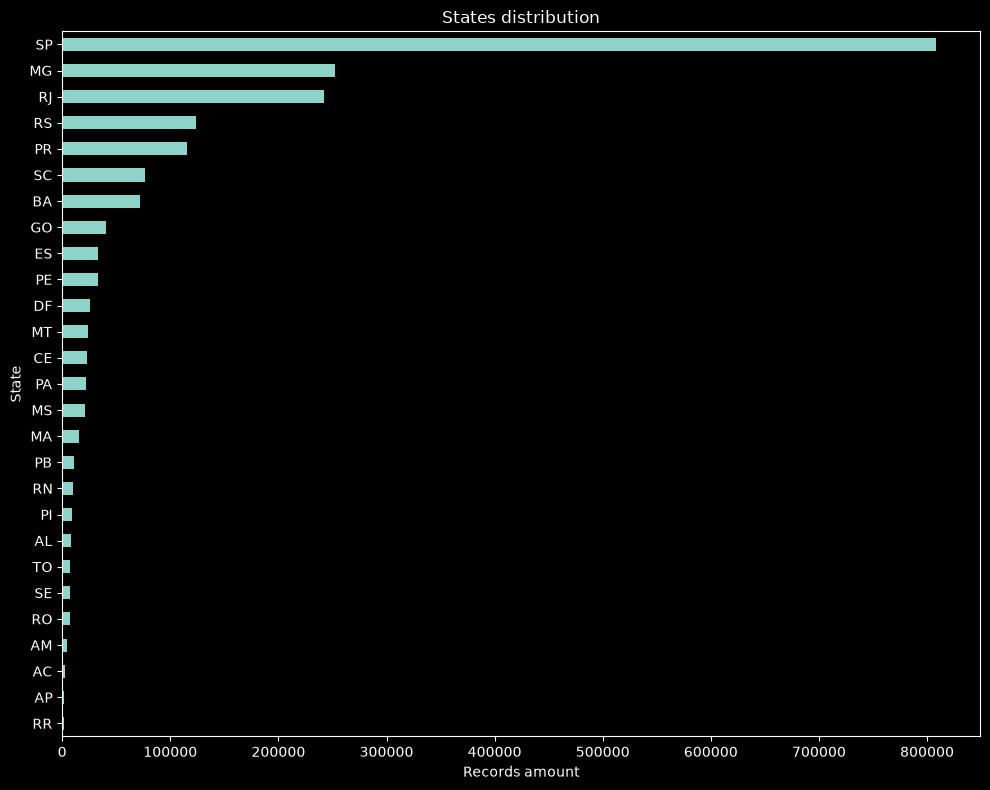

In [76]:
state_counts = df["geolocation_state"].value_counts()

plt.figure(figsize=(10, 8))

state_counts.sort_values().plot.barh()

plt.xlabel("Records amount")
plt.ylabel("State")
plt.title("States distribution")

plt.tight_layout()
plt.show()

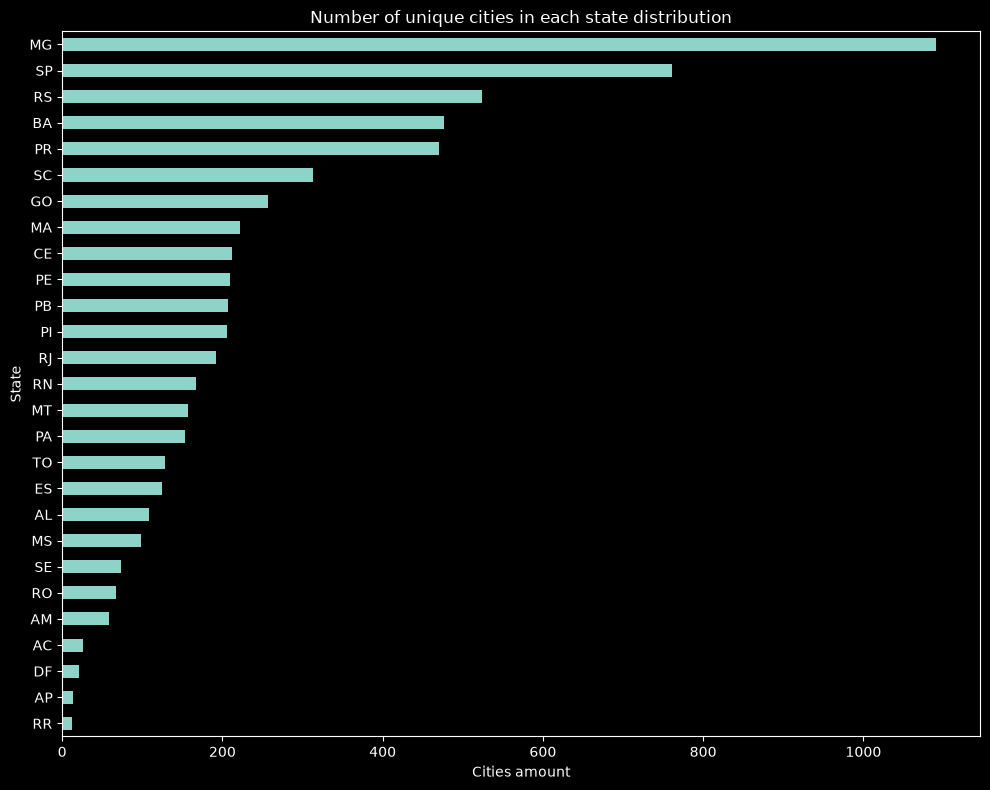

In [79]:
cities_by_state = (
    df.groupby("geolocation_state")["geolocation_city"]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 8))

cities_by_state.sort_values().plot.barh()

plt.xlabel("Cities amount")
plt.ylabel("State")
plt.title("Number of unique cities in each state distribution")

plt.tight_layout()
plt.show()

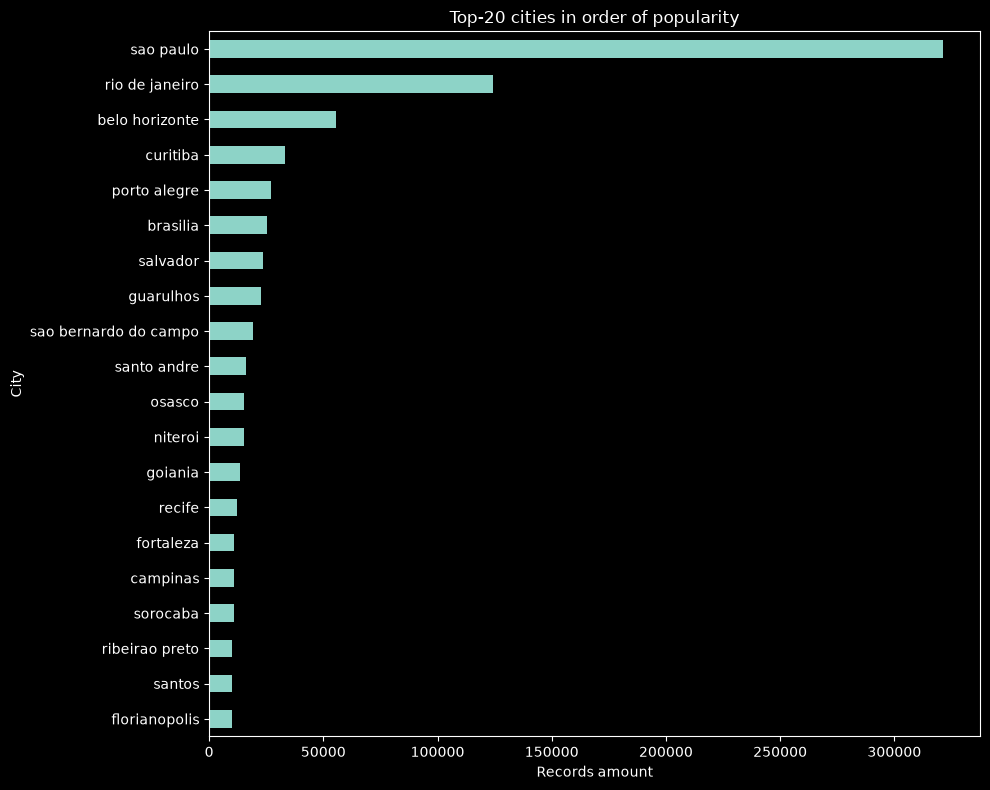

In [82]:
top_cities = (
    df["geolocation_city"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10, 8))

top_cities.sort_values().plot.barh()

plt.xlabel("Records amount")
plt.ylabel("City")
plt.title("Top-20 cities in order of popularity")

plt.tight_layout()
plt.show()

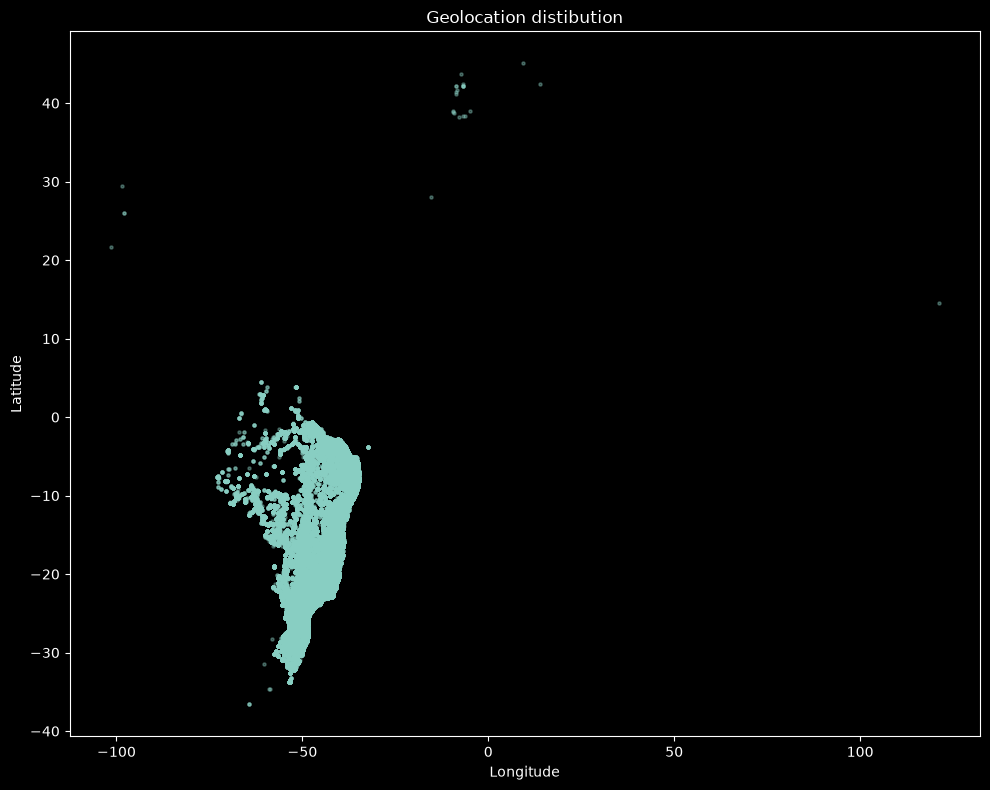

In [84]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df["geolocation_lng"],
    df["geolocation_lat"],
    alpha=0.2,
    s=5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geolocation distibution")

plt.tight_layout()
plt.show()

#### **PRODUCTS_CATEGORY_NAME_TRANSLATION**

In [90]:
read_sql_query = "SELECT * FROM product_category_name_translation"
df = pd.read_sql(sql=read_sql_query, con=connection)

In [91]:
df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


In [93]:
df.describe(include='all')

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [94]:
df.memory_usage(deep=True)

Index                             132
product_category_name            4684
product_category_name_english    4620
dtype: int64